# VINDy-C: Variational Identification of Nonlinear Dynamics (Controlled)
## Gaussian Likelihood · Gaussian Prior · Analytic Posterior · Iterative Bayesian Pruning

This notebook implements the full VINDy-C workflow:
- **Phase 2**: Library construction (17 physics-informed columns)
- **Phase 3**: Prior specification  
- **Phase 4**: Closed-form Bayesian posterior (analytic — no Adam/ELBO loop)
- **Phase 5**: Iterative Bayesian pruning (SNR-based thresholding)
- **Phase 6**: Model assessment (6 sequential checks)
- **Phase 7**: Tuning (if needed)
- **Phase 8**: Validation on held-out trajectories


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from scipy.linalg import inv

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("Imports loaded.")

Imports loaded.


## Phase 1 — Load VINDy Data
Load the data generated by `data_gen_vindy.py`.  
Dataset contains multiple trajectories with Gaussian-sampled Pacejka, mass, and CG parameters.


In [2]:
# ============================================================
# LOAD DATA
# ============================================================
data_path = Path("Data/vindy_data_rich_excitation.npz")
if not data_path.exists():
    data_path = Path("../Data/vindy_data_rich_excitation.npz")
if not data_path.exists():
    raise FileNotFoundError("Data/vindy_data_rich_excitation.npz not found. Run data_gen_vindy_smpc_rich_excitation.py first.")

data = np.load(data_path, allow_pickle=True)

# Training data
X_train  = data['X_train']    # [T, 5]: vx, vy, omega, alpha_f, alpha_r
Xd_train = data['Xd_train']   # [T, 3]: vx_dot, vy_dot, omega_dot
U_train  = data['U_train']    # [T, 2]: delta, Tr

# Validation data
X_val  = data['X_val']
Xd_val = data['Xd_val']
U_val  = data['U_val']

# Nominal parameters
nom = {k: float(data[f'nom_{k}']) for k in
       ['B_f','C_f','D_f','E_f','B_r','C_r','D_r','E_r',
        'M','Jz','lf','lr','R_wheel']}

# Training parameter samples (for ground truth comparison)
param_keys = ['B_f','C_f','D_f','E_f','B_r','C_r','D_r','E_r','M','Jz','lf','lr']
params_train = {k: data[f'ptrain_{k}'] for k in param_keys}
params_val   = {k: data[f'pval_{k}']   for k in param_keys}

T_train = X_train.shape[0]
T_val   = X_val.shape[0]

print(f"Training samples:   {T_train}")
print(f"Validation samples: {T_val}")
print(f"States:  [vx, vy, omega, alpha_f, alpha_r]")
print(f"Inputs:  [delta, Tr]")
print(f"Targets: [vx_dot, vy_dot, omega_dot]")


Training samples:   352751
Validation samples: 12816
States:  [vx, vy, omega, alpha_f, alpha_r]
Inputs:  [delta, Tr]
Targets: [vx_dot, vy_dot, omega_dot]


In [3]:
# Unpack state and input columns
vx    = X_train[:, 0]
vy    = X_train[:, 1]
omega = X_train[:, 2]
af    = X_train[:, 3]
ar    = X_train[:, 4]
delta = U_train[:, 0]
Tr    = U_train[:, 1]

print(f"Slip angle range (front): [{af.min()*180/np.pi:.1f}, {af.max()*180/np.pi:.1f}] deg")
print(f"Slip angle range (rear):  [{ar.min()*180/np.pi:.1f}, {ar.max()*180/np.pi:.1f}] deg")
print(f"Speed range: [{vx.min():.1f}, {vx.max():.1f}] m/s")


Slip angle range (front): [-12.0, 20.0] deg
Slip angle range (rear):  [-6.8, 7.6] deg
Speed range: [8.9, 31.4] m/s


## Phase 2 — Library Construction (VINDy-C)

Build a **richer-than-needed** physics-informed library with 17 candidate columns.  
VINDy-C: states **and** inputs appear in the library.  
Signs are **NOT** pre-baked — VINDy identifies sign through coefficient value.

**Expected pruning outcome:**
- Survive: Coriolis (θ₁,θ₂), Tr drive (θ₅), tire linear/cubic terms
- Pruned: vx drag (θ₃), vy (θ₄), direct δ (θ₆), quintic, speed-scheduled


In [4]:
# ============================================================
# BUILD FULL CANDIDATE LIBRARY — EXPANDED
# ============================================================

theta_cols = []
theta_names = []

# --- Structural (state only) ---
theta_cols.append(omega * vy);               theta_names.append('omega*vy')
theta_cols.append(omega * vx);               theta_names.append('omega*vx')
theta_cols.append(vx.copy());                theta_names.append('vx')
theta_cols.append(vy.copy());                theta_names.append('vy')

# --- Input direct ---
theta_cols.append(Tr.copy());                theta_names.append('Tr')
theta_cols.append(delta.copy());             theta_names.append('delta')

# --- Front tire: odd polynomial × input projections ---
for power in [1, 3, 5]:
    theta_cols.append(af**power * np.sin(delta))
    theta_names.append(f'af^{power}*sin(d)' if power > 1 else 'af*sin(d)')
    theta_cols.append(af**power * np.cos(delta))
    theta_names.append(f'af^{power}*cos(d)' if power > 1 else 'af*cos(d)')

# --- Rear tire: odd polynomial ---
for power in [1, 3, 5]:
    theta_cols.append(ar**power)
    theta_names.append(f'ar^{power}' if power > 1 else 'ar')

# --- Speed-scheduled stiffness (cross terms) ---
theta_cols.append(vx * af * np.cos(delta));  theta_names.append('vx*af*cos(d)')
theta_cols.append(vx * ar);                  theta_names.append('vx*ar')

Theta = np.column_stack(theta_cols)
p = Theta.shape[1]

print(f"Library Theta shape: {Theta.shape}  ({p} columns)")
print("\nLibrary terms:")
for i, name in enumerate(theta_names):
    print(f"  [{i:2d}] {name}")

Library Theta shape: (352751, 17)  (17 columns)

Library terms:
  [ 0] omega*vy
  [ 1] omega*vx
  [ 2] vx
  [ 3] vy
  [ 4] Tr
  [ 5] delta
  [ 6] af*sin(d)
  [ 7] af*cos(d)
  [ 8] af^3*sin(d)
  [ 9] af^3*cos(d)
  [10] af^5*sin(d)
  [11] af^5*cos(d)
  [12] ar
  [13] ar^3
  [14] ar^5
  [15] vx*af*cos(d)
  [16] vx*ar


### Collinearity Check
Compute condition number κ(Θ) and VIF per column.  
κ > 10³ → collinear columns must be addressed before proceeding.


Condition number κ(Θ) = 434.4
  ✓ κ < 10³ — acceptable


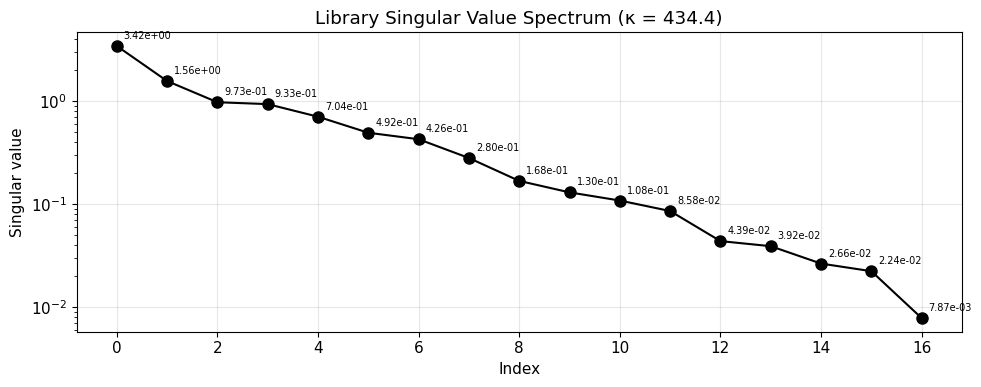

In [5]:
# ============================================================
# COLLINEARITY CHECK
# ============================================================

# Normalize columns for condition number check
col_norms = np.linalg.norm(Theta, axis=0)
col_norms[col_norms == 0] = 1.0
Theta_n = Theta / col_norms

# SVD and condition number
U_svd, s_svd, Vt_svd = np.linalg.svd(Theta_n, full_matrices=False)
kappa = s_svd[0] / s_svd[-1]

print(f"Condition number κ(Θ) = {kappa:.1f}")
if kappa > 1e3:
    print("  ⚠ κ > 10³ — collinearity detected!")
else:
    print("  ✓ κ < 10³ — acceptable")

# Singular value spectrum
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(s_svd, 'ko-', ms=8)
ax.set_xlabel('Index')
ax.set_ylabel('Singular value')
ax.set_title(f'Library Singular Value Spectrum (κ = {kappa:.1f})')
ax.grid(True, alpha=0.3)
for i, s in enumerate(s_svd):
    ax.annotate(f'{s:.2e}', (i, s), textcoords="offset points",
                xytext=(5, 5), fontsize=7)
plt.tight_layout()
plt.show()


In [6]:
# VIF (Variance Inflation Factor) per column
from sklearn.linear_model import LinearRegression

def compute_vif(Theta):
    p = Theta.shape[1]
    vifs = np.zeros(p)
    for j in range(p):
        y_j = Theta[:, j]
        X_j = np.delete(Theta, j, axis=1)
        r2 = LinearRegression().fit(X_j, y_j).score(X_j, y_j)
        vifs[j] = 1.0 / (1.0 - r2 + 1e-10)
    return vifs

vifs = compute_vif(Theta_n)

print("VIF per column:")
print(f"  {'Column':<20s}  {'VIF':>10s}  {'Flag':>6s}")
print("  " + "-"*40)
for i, (name, vif) in enumerate(zip(theta_names, vifs)):
    flag = " ⚠" if vif > 10 else ""
    print(f"  {name:<20s}  {vif:10.1f}  {flag}")


VIF per column:
  Column                       VIF    Flag
  ----------------------------------------
  omega*vy                    11.4   ⚠
  omega*vx                   448.6   ⚠
  vx                           2.2  
  vy                        2430.6   ⚠
  Tr                           1.1  
  delta                      810.0   ⚠
  af*sin(d)                   68.2   ⚠
  af*cos(d)                 1049.7   ⚠
  af^3*sin(d)                636.6   ⚠
  af^3*cos(d)                664.2   ⚠
  af^5*sin(d)                436.3   ⚠
  af^5*cos(d)                772.0   ⚠
  ar                         648.5   ⚠
  ar^3                        83.2   ⚠
  ar^5                        24.4   ⚠
  vx*af*cos(d)               567.0   ⚠
  vx*ar                     6716.6   ⚠


### Collinearity Resolution
**Physics-guided**, not blind VIF removal.  
Essential terms (Coriolis, Tr, linear tire, cubic tire) are **protected**.  
Only removable terms (quintic, drag-like, direct δ, speed-scheduled) are candidates for removal.


In [7]:
# ============================================================
# PHYSICS-GUIDED COLLINEARITY REMOVAL
# ============================================================

# Updated protected set
protected = {'omega*vy', 'omega*vx', 'Tr',
             'af*sin(d)', 'af*cos(d)', 
             'af^3*sin(d)', 'af^3*cos(d)',
             'af^5*sin(d)', 'af^5*cos(d)',
             'af^7*sin(d)', 'af^7*cos(d)',
             'af^9*sin(d)', 'af^9*cos(d)',
             'ar', 'ar^3', 'ar^5', 'ar^7', 'ar^9'}

# Removable terms — only these can be dropped for collinearity
removable = {'vx', 'vy', 'delta',
             'vx*af*cos(d)', 'vx*ar'}

Theta_clean = Theta.copy()
names_clean = list(theta_names)
removed_cols = []

MAX_ITER = 10
for iteration in range(MAX_ITER):
    col_norms_c = np.linalg.norm(Theta_clean, axis=0)
    col_norms_c[col_norms_c == 0] = 1.0
    Theta_c_n = Theta_clean / col_norms_c

    # Check condition number — stop if acceptable
    s_check = np.linalg.svd(Theta_c_n, compute_uv=False)
    kappa_check = s_check[0] / s_check[-1]
    if kappa_check < 1e3:
        print(f"  κ = {kappa_check:.1f} < 10³ — acceptable, stopping removal.")
        break

    # Compute VIF
    vifs_c = compute_vif(Theta_c_n)

    # Find highest VIF among REMOVABLE columns only
    removable_mask = np.array([n in removable for n in names_clean])
    if not removable_mask.any():
        print(f"  No removable columns left. Final κ = {kappa_check:.1f}")
        break

    vifs_removable = np.where(removable_mask, vifs_c, 0)
    max_idx = vifs_removable.argmax()
    max_vif = vifs_removable[max_idx]

    if max_vif < 10.0:
        print(f"  All removable columns have VIF < 10. Final κ = {kappa_check:.1f}")
        break

    removed_name = names_clean[max_idx]
    removed_cols.append(removed_name)
    print(f"  Iter {iteration+1}: Removing '{removed_name}' (VIF = {max_vif:.1f}, κ = {kappa_check:.1f})")

    Theta_clean = np.delete(Theta_clean, max_idx, axis=1)
    names_clean.pop(max_idx)

# Final condition number
col_norms_final = np.linalg.norm(Theta_clean, axis=0)
col_norms_final[col_norms_final == 0] = 1.0
s_final = np.linalg.svd(Theta_clean / col_norms_final, compute_uv=False)
kappa_final = s_final[0] / s_final[-1]

p_clean = Theta_clean.shape[1]

print(f"\nFinal library: {p_clean} columns (removed {len(removed_cols)})")
print(f"Final κ(Θ) = {kappa_final:.1f}")
print(f"Removed: {removed_cols}")
print(f"\nSurviving columns:")
for i, name in enumerate(names_clean):
    flag = " [protected]" if name in protected else " [removable]"
    print(f"  [{i:2d}] {name}{flag}")

# Use cleaned library going forward
Theta_lib = Theta_clean
lib_names = names_clean
p_lib = p_clean


  κ = 434.4 < 10³ — acceptable, stopping removal.

Final library: 17 columns (removed 0)
Final κ(Θ) = 434.4
Removed: []

Surviving columns:
  [ 0] omega*vy [protected]
  [ 1] omega*vx [protected]
  [ 2] vx [removable]
  [ 3] vy [removable]
  [ 4] Tr [protected]
  [ 5] delta [removable]
  [ 6] af*sin(d) [protected]
  [ 7] af*cos(d) [protected]
  [ 8] af^3*sin(d) [protected]
  [ 9] af^3*cos(d) [protected]
  [10] af^5*sin(d) [protected]
  [11] af^5*cos(d) [protected]
  [12] ar [protected]
  [13] ar^3 [protected]
  [14] ar^5 [protected]
  [15] vx*af*cos(d) [removable]
  [16] vx*ar [removable]


Testing 

In [8]:
def build_vehicle_library(X, U):
    """
    X columns:
        [vx, vy, omega, alpha_f, alpha_r]

    U columns:
        [delta, Tr]

    Returns:
        Theta, terms
    """
    vx = X[:, 0]
    vy = X[:, 1]
    omega = X[:, 2]
    af = X[:, 3]
    ar = X[:, 4]

    delta = U[:, 0]
    Tr = U[:, 1]

    s = np.sin(delta)
    c = np.cos(delta)

    Theta = np.column_stack([
        omega * vy,          # 0
        omega * vx,          # 1
        vx,                  # 2
        vy,                  # 3
        Tr,                  # 4
        delta,               # 5
        af * s,              # 6
        af * c,              # 7
        af**3 * s,           # 8
        af**3 * c,           # 9
        af**5 * s,           # 10
        af**5 * c,           # 11
        ar,                  # 12
        ar**3,               # 13
        ar**5,               # 14
        vx * af * c,         # 15
        vx * ar,             # 16
    ])

    terms = [
        "omega*vy",
        "omega*vx",
        "vx",
        "vy",
        "Tr",
        "delta",
        "af*sin(d)",
        "af*cos(d)",
        "af^3*sin(d)",
        "af^3*cos(d)",
        "af^5*sin(d)",
        "af^5*cos(d)",
        "ar",
        "ar^3",
        "ar^5",
        "vx*af*cos(d)",
        "vx*ar",
    ]

    return Theta, terms


Theta_train, terms = build_vehicle_library(X_train, U_train)
Theta_val, _ = build_vehicle_library(X_val, U_val)

print(f"Library Theta shape: {Theta_train.shape}")
print("Library terms:")
for i, t in enumerate(terms):
    print(f"  [{i:2d}] {t}")



# ============================================================
# Channel-specific physically allowed terms
# ============================================================

active_terms_by_channel = {
    "vx_dot": [
        "omega*vy",
        "Tr",
        "af*sin(d)",
        "af^3*sin(d)",
        "af^5*sin(d)",
    ],

    "vy_dot": [
        "omega*vx",
        "af*cos(d)",
        "af^3*cos(d)",
        "af^5*cos(d)",
        "ar",
        "ar^3",
        "ar^5",
    ],

    "omega_dot": [
        "af*cos(d)",
        "af^3*cos(d)",
        "af^5*cos(d)",
        "ar",
        "ar^3",
        "ar^5",
    ],
}

term_to_idx = {t: i for i, t in enumerate(terms)}

active_idx_by_channel = {
    ch: np.array([term_to_idx[t] for t in active_terms], dtype=int)
    for ch, active_terms in active_terms_by_channel.items()
}

for ch, idx in active_idx_by_channel.items():
    print(f"\n{ch}:")
    for i in idx:
        print(f"  [{i:2d}] {terms[i]}")


Library Theta shape: (352751, 17)
Library terms:
  [ 0] omega*vy
  [ 1] omega*vx
  [ 2] vx
  [ 3] vy
  [ 4] Tr
  [ 5] delta
  [ 6] af*sin(d)
  [ 7] af*cos(d)
  [ 8] af^3*sin(d)
  [ 9] af^3*cos(d)
  [10] af^5*sin(d)
  [11] af^5*cos(d)
  [12] ar
  [13] ar^3
  [14] ar^5
  [15] vx*af*cos(d)
  [16] vx*ar

vx_dot:
  [ 0] omega*vy
  [ 4] Tr
  [ 6] af*sin(d)
  [ 8] af^3*sin(d)
  [10] af^5*sin(d)

vy_dot:
  [ 1] omega*vx
  [ 7] af*cos(d)
  [ 9] af^3*cos(d)
  [11] af^5*cos(d)
  [12] ar
  [13] ar^3
  [14] ar^5

omega_dot:
  [ 7] af*cos(d)
  [ 9] af^3*cos(d)
  [11] af^5*cos(d)
  [12] ar
  [13] ar^3
  [14] ar^5


## Phase 3 — Prior Specification

Assign σ_prior per column based on physical scale.  
Gaussian prior → **shrinkage, not sparsity**. Pruning is handled separately in Phase 5.


In [9]:
# ============================================================
# Raw coefficient priors
# ============================================================
# These are priors on the raw, unstandardized Theta columns.

sigma_prior_raw = {
    # inertial coupling
    "omega*vy": 5.0,
    "omega*vx": 5.0,

    # direct standalone terms: discouraged
    "vx": 0.05,
    "vy": 0.05,
    "delta": 0.05,

    # torque true scale is roughly 1 / (M * R_wheel) ≈ 0.0022
    "Tr": 0.01,

    # front tire projected through sin(delta), mostly affects vx_dot
    "af*sin(d)": 100.0,
    "af^3*sin(d)": 3000.0,
    "af^5*sin(d)": 50000.0,

    # front tire projected through cos(delta), affects vy_dot and omega_dot
    "af*cos(d)": 100.0,
    "af^3*cos(d)": 3000.0,
    "af^5*cos(d)": 50000.0,

    # rear tire
    "ar": 100.0,
    "ar^3": 3000.0,
    "ar^5": 50000.0,

    # compensation terms: discouraged
    "vx*af*cos(d)": 0.05,
    "vx*ar": 0.05,
}

print("Priors used by active channel terms:")
for ch, active_terms in active_terms_by_channel.items():
    print(f"\n{ch}:")
    for t in active_terms:
        print(f"  {t:20s} σ_prior = {sigma_prior_raw[t]:.4g}")

Priors used by active channel terms:

vx_dot:
  omega*vy             σ_prior = 5
  Tr                   σ_prior = 0.01
  af*sin(d)            σ_prior = 100
  af^3*sin(d)          σ_prior = 3000
  af^5*sin(d)          σ_prior = 5e+04

vy_dot:
  omega*vx             σ_prior = 5
  af*cos(d)            σ_prior = 100
  af^3*cos(d)          σ_prior = 3000
  af^5*cos(d)          σ_prior = 5e+04
  ar                   σ_prior = 100
  ar^3                 σ_prior = 3000
  ar^5                 σ_prior = 5e+04

omega_dot:
  af*cos(d)            σ_prior = 100
  af^3*cos(d)          σ_prior = 3000
  af^5*cos(d)          σ_prior = 5e+04
  ar                   σ_prior = 100
  ar^3                 σ_prior = 3000
  ar^5                 σ_prior = 5e+04


## Phase 4 — Closed-Form Bayesian Posterior

$$\Sigma_{\text{post}} = \left(\frac{\Theta^\top\Theta}{\sigma_\varepsilon^2} + \Lambda\right)^{-1}$$

$$\mu_c = \frac{1}{\sigma_\varepsilon^2}\Sigma_{\text{post}}\,\Theta^\top\dot{x}_c$$

One matrix inversion — replaces the entire ELBO/Adam loop.  
Exact global optimum of VINDy's objective under Gaussian assumptions.


In [10]:
# ============================================================
# Bayesian linear regression, channel-specific active library
# ============================================================

channel_names = ["vx_dot", "vy_dot", "omega_dot"]

def estimate_sigma_eps_ols(Theta_c, y):
    """
    Estimate noise std from OLS residuals using the active channel library.
    """
    beta_ols, *_ = np.linalg.lstsq(Theta_c, y, rcond=None)
    resid = y - Theta_c @ beta_ols

    dof = max(len(y) - Theta_c.shape[1], 1)
    sigma = np.sqrt(np.sum(resid**2) / dof)

    return float(sigma), beta_ols, resid


def bayesian_fit_channel_raw(Theta, y, terms, active_terms, sigma_prior_raw, sigma_eps):
    """
    Bayesian linear regression:

        y = Theta_active @ xi + eps

    with:
        eps ~ N(0, sigma_eps^2)
        xi_j ~ N(0, sigma_prior_j^2)

    Returns full-size coefficient vector and covariance matrix.
    """
    term_to_idx = {t: i for i, t in enumerate(terms)}
    active_idx = np.array([term_to_idx[t] for t in active_terms], dtype=int)

    Theta_c = Theta[:, active_idx]

    sigma_prior_c = np.array(
        [sigma_prior_raw[t] for t in active_terms],
        dtype=float
    )

    Lambda = np.diag(1.0 / (sigma_prior_c**2))

    A = (Theta_c.T @ Theta_c) / (sigma_eps**2) + Lambda
    b = (Theta_c.T @ y) / (sigma_eps**2)

    mu_c = np.linalg.solve(A, b)
    Sigma_c = np.linalg.inv(A)

    n_terms = len(terms)
    mu_full = np.zeros(n_terms)
    Sigma_full = np.zeros((n_terms, n_terms))

    mu_full[active_idx] = mu_c

    for ii, i_full in enumerate(active_idx):
        for jj, j_full in enumerate(active_idx):
            Sigma_full[i_full, j_full] = Sigma_c[ii, jj]

    return mu_full, Sigma_full, active_idx


mu_post = {}
Sigma_post = {}
sigma_eps_by_channel = {}
active_idx_post = {}
ols_resid_by_channel = {}

for j, ch in enumerate(channel_names):
    active_terms = active_terms_by_channel[ch]
    active_idx = active_idx_by_channel[ch]

    Theta_c = Theta_train[:, active_idx]
    y = Xd_train[:, j]

    sigma_eps, beta_ols, resid = estimate_sigma_eps_ols(Theta_c, y)

    mu_full, Sigma_full, active_idx = bayesian_fit_channel_raw(
        Theta=Theta_train,
        y=y,
        terms=terms,
        active_terms=active_terms,
        sigma_prior_raw=sigma_prior_raw,
        sigma_eps=sigma_eps,
    )

    mu_post[ch] = mu_full
    Sigma_post[ch] = Sigma_full
    sigma_eps_by_channel[ch] = sigma_eps
    active_idx_post[ch] = active_idx
    ols_resid_by_channel[ch] = resid

print("Auto-tuned σ_ε per channel, using physical active library:")
for ch in channel_names:
    print(f"  {ch:10s}: σ_ε = {sigma_eps_by_channel[ch]:.6f}")

Auto-tuned σ_ε per channel, using physical active library:
  vx_dot    : σ_ε = 0.115646
  vy_dot    : σ_ε = 0.398899
  omega_dot : σ_ε = 0.243792


## Phase 5 — Iterative Bayesian Pruning

SNR-based thresholding: prune terms where |μ| / σ < γ (default γ = 2.0).  
Re-solve on surviving support after each pruning step.  
This is the Bayesian analog of SINDy's STLSQ.


In [11]:
# ============================================================
# ITERATIVE BAYESIAN PRUNING
# ============================================================

gamma = 0   # SNR threshold (two-sigma significance)

print(gamma)

def bayesian_posterior(Theta_A, Lambda_A, xdot_c, sigma_eps):
    """Compute closed-form posterior on active support."""
    TtT_A = Theta_A.T @ Theta_A
    A = TtT_A / sigma_eps**2 + Lambda_A
    rhs = Theta_A.T @ xdot_c / sigma_eps**2
    mu_A = np.linalg.solve(A, rhs)
    Sigma_A = np.linalg.solve(A, np.eye(A.shape[0]))
    sigma_A = np.sqrt(np.diag(Sigma_A))
    return mu_A, Sigma_A, sigma_A


# Per-channel pruning
pruning_results = {}

for c, ch_name in enumerate(channel_names):
    print(f"\n{'='*60}")
    print(f"  Channel: {ch_name}  (σ_ε = {sigma_eps_per_ch[ch_name]:.6f})")
    print(f"{'='*60}")

    active = list(range(p_lib))
    xdot_c = Xd_train[:, c]
    sigma_eps = sigma_eps_per_ch[ch_name]

    for iteration in range(20):
        Theta_A = Theta_lib[:, active]
        Lambda_A = np.diag([1.0 / sigma_prior[j]**2 for j in active])

        mu_A, Sigma_A, sigma_A = bayesian_posterior(Theta_A, Lambda_A, xdot_c, sigma_eps)

        # Compute SNR
        snr = np.abs(mu_A) / sigma_A

        # Identify surviving set
        survive = snr >= gamma
        active_new = [active[j] for j in range(len(active)) if survive[j]]

        # Report pruned terms
        pruned_this_iter = [active[j] for j in range(len(active)) if not survive[j]]
        if pruned_this_iter:
            print(f"  Iter {iteration+1}: pruned {[lib_names[j] for j in pruned_this_iter]}")
            for j_idx in [j for j in range(len(active)) if not survive[j]]:
                print(f"    {lib_names[active[j_idx]]}: μ={mu_A[j_idx]:+.6f}, "
                      f"σ={sigma_A[j_idx]:.6f}, SNR={snr[j_idx]:.2f}")

        if active_new == active:
            print(f"  Converged after {iteration+1} iteration(s).")
            break

        active = active_new

        if len(active) == 0:
            print(f"  All terms pruned at iteration {iteration+1}.")
            mu_A = np.array([])
            Sigma_A = np.array([]).reshape(0, 0)
            sigma_A = np.array([])
            snr = np.array([])
            break

    # Final solve on converged support
    if len(active) > 0:
        Theta_A = Theta_lib[:, active]
        Lambda_A = np.diag([1.0 / sigma_prior[j]**2 for j in active])
        mu_A, Sigma_A, sigma_A = bayesian_posterior(Theta_A, Lambda_A, xdot_c, sigma_eps)
        snr_final = np.abs(mu_A) / sigma_A
    else:
        snr_final = np.array([])

    pruning_results[ch_name] = {
        'active': active,
        'mu': mu_A,
        'Sigma': Sigma_A,
        'sigma': sigma_A,
        'snr': snr_final,
        'names': [lib_names[j] for j in active],
        'sigma_eps': sigma_eps,
    }

    print(f"\n  Surviving terms ({len(active)}/{p_lib}):")
    print(f"  {'Term':<20s}  {'μ':>12s}  {'σ':>10s}  {'SNR':>8s}  {'Label':>10s}")
    print("  " + "-"*65)
    for j_local, j_orig in enumerate(active):
        cov = sigma_A[j_local] / abs(mu_A[j_local]) if abs(mu_A[j_local]) > 1e-15 else 999
        label = "confident" if cov < 0.2 else ("moderate" if cov < 0.5 else "uncertain")
        print(f"  {lib_names[j_orig]:<20s}  {mu_A[j_local]:+12.6f}  "
              f"{sigma_A[j_local]:10.6f}  {snr_final[j_local]:8.1f}  {label:>10s}")


0



NameError: name 'sigma_eps_per_ch' is not defined

### Pruning Summary
All 17 (or post-κ) library terms with final status per channel.


In [ ]:
# ============================================================
# PRUNING SUMMARY TABLE
# ============================================================

print(f"{'Term':<20s}  {'vx_dot':>8s}  {'vy_dot':>8s}  {'ω_dot':>8s}")
print("-"*50)

for j, name in enumerate(lib_names):
    status = []
    for ch_name in channel_names:
        if j in pruning_results[ch_name]['active']:
            idx = pruning_results[ch_name]['active'].index(j)
            snr = pruning_results[ch_name]['snr'][idx]
            status.append(f"✓ {snr:.1f}")
        else:
            status.append("✗")
    print(f"{name:<20s}  {status[0]:>8s}  {status[1]:>8s}  {status[2]:>8s}")


## Phase 6 — Model Assessment

### Check 1: R² (Point Prediction Quality)


In [12]:
# ============================================================
# Training and validation predictions
# ============================================================

def predict_channels(Theta, mu_post, channel_names):
    Y_pred = np.zeros((Theta.shape[0], len(channel_names)))

    for j, ch in enumerate(channel_names):
        Y_pred[:, j] = Theta @ mu_post[ch]

    return Y_pred


Xd_train_pred = predict_channels(Theta_train, mu_post, channel_names)
Xd_val_pred = predict_channels(Theta_val, mu_post, channel_names)


def regression_metrics(y_true, y_pred):
    err = y_true - y_pred

    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    bias = np.mean(err)
    nrmse = rmse / (np.std(y_true) + 1e-12)

    ss_res = np.sum(err**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2) + 1e-12
    r2 = 1.0 - ss_res / ss_tot

    return rmse, mae, bias, nrmse, r2


print("\nR² and error metrics:")

for split_name, Y_true, Y_pred in [
    ("TRAIN", Xd_train, Xd_train_pred),
    ("VAL", Xd_val, Xd_val_pred),
]:
    print("\n" + "="*70)
    print(split_name)
    print("="*70)

    for j, ch in enumerate(channel_names):
        rmse, mae, bias, nrmse, r2 = regression_metrics(Y_true[:, j], Y_pred[:, j])

        status = "PASS" if r2 > 0.90 else "FAIL"

        print(
            f"{ch:10s} | "
            f"RMSE={rmse:10.5f} | "
            f"NRMSE={nrmse:8.4f} | "
            f"Bias={bias:+10.5f} | "
            f"R²={r2:9.6f} | {status}"
        )


R² and error metrics:

TRAIN
vx_dot     | RMSE=   0.11565 | NRMSE=  0.0886 | Bias=  -0.00167 | R²= 0.992143 | PASS
vy_dot     | RMSE=   0.39890 | NRMSE=  0.5768 | Bias=  +0.02387 | R²= 0.667255 | FAIL
omega_dot  | RMSE=   0.24379 | NRMSE=  0.6461 | Bias=  +0.00715 | R²= 0.582509 | FAIL

VAL
vx_dot     | RMSE=   0.11543 | NRMSE=  0.0884 | Bias=  +0.00488 | R²= 0.992181 | PASS
vy_dot     | RMSE=   0.41503 | NRMSE=  0.5715 | Bias=  -0.03580 | R²= 0.673444 | FAIL
omega_dot  | RMSE=   0.24458 | NRMSE=  0.6028 | Bias=  +0.02112 | R²= 0.636574 | FAIL


### Check 2: Residual Calibration


KeyError: 'vx_dot'

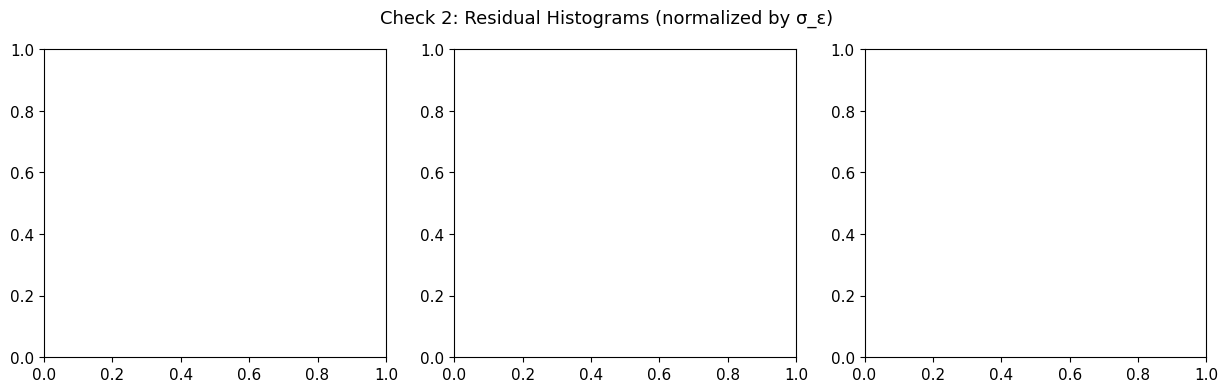

In [13]:
# ============================================================
# CHECK 2a,b — Residual histogram + empirical std vs σ_ε
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Check 2: Residual Histograms (normalized by σ_ε)', fontsize=13)

for c, (ax, ch_name) in enumerate(zip(axes, channel_names)):
    pr = pruning_results[ch_name]
    Theta_A = Theta_lib[:, pr['active']]
    xdot_pred = Theta_A @ pr['mu']
    residual = Xd_train[:, c] - xdot_pred
    sigma_eps = sigma_eps_per_ch[ch_name]
    r_norm = residual / sigma_eps

    sigma_r = residual.std()
    ax.hist(r_norm, bins=100, density=True, alpha=0.7, edgecolor='k', label='Residual')

    # Overlay N(0,1)
    x_range = np.linspace(-5, 5, 200)
    ax.plot(x_range, norm.pdf(x_range), 'r-', lw=2, label='N(0,1)')

    ax.set_xlabel(f'r / σ_ε')
    ax.set_title(f'{ch_name}\nσ_r={sigma_r:.4f}, σ_ε={sigma_eps:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print diagnostic
print("Residual std vs σ_ε:")
for c, ch_name in enumerate(channel_names):
    pr = pruning_results[ch_name]
    Theta_A = Theta_lib[:, pr['active']]
    residual = Xd_train[:, c] - Theta_A @ pr['mu']
    sigma_eps = sigma_eps_per_ch[ch_name]
    sigma_r = residual.std()
    ratio = sigma_r / sigma_eps
    flag = "✓" if 0.5 < ratio < 2.0 else "⚠ TUNE σ_ε"
    print(f"  {ch_name}: σ_r = {sigma_r:.6f},  σ_r/σ_ε = {ratio:.2f}  {flag}")


In [ ]:
# ============================================================
# CHECK 2c — Residual vs state/input correlation
# ============================================================

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Check 2c: Residual vs State Correlation', fontsize=13)

state_labels = ['vx', 'vy', 'omega', 'α_f', 'α_r']

for c, ch_name in enumerate(channel_names):
    pr = pruning_results[ch_name]
    Theta_A = Theta_lib[:, pr['active']]
    residual = Xd_train[:, c] - Theta_A @ pr['mu']

    # Subsample for plotting only
    plot_idx = np.random.choice(len(residual), size=min(10000, len(residual)), replace=False)

    for s, (ax, s_name) in enumerate(zip(axes[c], state_labels)):
        state_col = X_train[:, s]
        corr = np.corrcoef(residual, state_col)[0, 1]          # full data
        ax.scatter(state_col[plot_idx], residual[plot_idx], s=0.5, alpha=0.1, rasterized=True)  # subsampled

plt.tight_layout()
plt.show()


### Check 3: Posterior Predictive Coverage
The core VINDy-specific check — do the uncertainty estimates match reality?


KeyError: 'vx_dot'

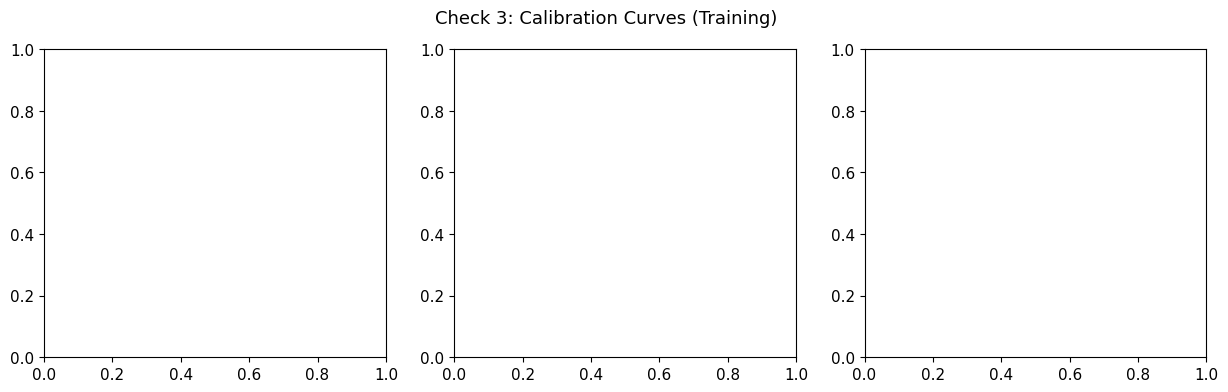

In [14]:
# ============================================================
# CHECK 3 — POSTERIOR PREDICTIVE COVERAGE
# ============================================================

confidence_levels = [0.50, 0.75, 0.90, 0.95, 0.99]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Check 3: Calibration Curves (Training)', fontsize=13)

for c, (ax, ch_name) in enumerate(zip(axes, channel_names)):
    pr = pruning_results[ch_name]
    Theta_A = Theta_lib[:, pr['active']]
    mu_pred = Theta_A @ pr['mu']
    Sigma_A = pr['Sigma']
    sigma_eps = sigma_eps_per_ch[ch_name]

    # Predictive variance per sample: σ²_ε + θ_t^T Σ_post θ_t
    # Efficient: (Theta_A @ Sigma_A) element-wise * Theta_A, sum over columns
    param_var = np.sum((Theta_A @ Sigma_A) * Theta_A, axis=1)
    sigma_pred = np.sqrt(sigma_eps**2 + param_var)

    residual = Xd_train[:, c] - mu_pred

    coverages = []
    for alpha in confidence_levels:
        z = norm.ppf(1 - (1 - alpha) / 2)
        in_interval = np.abs(residual) <= z * sigma_pred
        cov = in_interval.mean()
        coverages.append(cov)

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')
    ax.plot(confidence_levels, coverages, 'bo-', ms=8, lw=2, label='Actual')
    ax.set_xlabel('Predicted coverage')
    ax.set_ylabel('Actual coverage')
    ax.set_title(ch_name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.4, 1.02)
    ax.set_ylim(0.4, 1.02)

    # Print
    for alpha, cov in zip(confidence_levels, coverages):
        flag = "✓" if abs(cov - alpha) < 0.03 else "⚠"
        print(f"  {ch_name} {alpha*100:.0f}%: actual={cov*100:.1f}%  {flag}")

plt.tight_layout()
plt.show()


### Check 4: Tire Curve Posterior vs True Pacejka
Since data is synthetic, we can compare VINDy's posterior tire curves against ground truth.


In [15]:
# ============================================================
# CHECK 4 — TIRE CURVE POSTERIOR vs TRUE PACEJKA
# ============================================================

def pacejka(alpha, B, C, D, E):
    Ba = B * alpha
    return D * np.sin(C * np.arctan(Ba - E * (Ba - np.arctan(Ba))))

alpha_range = np.linspace(-0.15, 0.15, 500)   # rad (~±8.6 deg)

# Use vy_dot channel for tire coefficient extraction
pr_vy = pruning_results['vy_dot']
vy_names = pr_vy['names']

# Find front and rear tire indices in vy channel
front_lin_idx = [i for i, n in enumerate(vy_names) if n == 'af*cos(d)']
front_cub_idx = [i for i, n in enumerate(vy_names) if n == 'af^3*cos(d)']
rear_lin_idx  = [i for i, n in enumerate(vy_names) if n == 'ar']
rear_cub_idx  = [i for i, n in enumerate(vy_names) if n == 'ar^3']

has_front = len(front_lin_idx) > 0
has_rear  = len(rear_lin_idx) > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Check 4: Posterior Tire Curves vs True Pacejka', fontsize=13)

S_plot = 200

if has_front and len(front_cub_idx) > 0:
    front_idx = front_lin_idx + front_cub_idx
    mu_front = pr_vy['mu'][front_idx]
    Sigma_front = pr_vy['Sigma'][np.ix_(front_idx, front_idx)]

    # Sample posterior tire curves
    for s in range(S_plot):
        c_sample = np.random.multivariate_normal(mu_front, Sigma_front)
        F_sample = c_sample[0] * alpha_range + c_sample[1] * alpha_range**3
        axes[0].plot(alpha_range * 180/np.pi, F_sample, 'b-', alpha=0.05, lw=0.5)

    # Posterior mean
    F_mean = mu_front[0] * alpha_range + mu_front[1] * alpha_range**3
    axes[0].plot(alpha_range * 180/np.pi, F_mean, 'b-', lw=2, label='VINDy posterior mean')
elif has_front:
    front_idx = front_lin_idx
    mu_front = pr_vy['mu'][front_idx]
    for s in range(S_plot):
        c1 = np.random.normal(mu_front[0], pr_vy['sigma'][front_idx[0]])
        F_sample = c1 * alpha_range
        axes[0].plot(alpha_range * 180/np.pi, F_sample, 'b-', alpha=0.05, lw=0.5)
    F_mean = mu_front[0] * alpha_range
    axes[0].plot(alpha_range * 180/np.pi, F_mean, 'b-', lw=2, label='VINDy posterior mean')

if has_rear and len(rear_cub_idx) > 0:
    rear_idx = rear_lin_idx + rear_cub_idx
    mu_rear = pr_vy['mu'][rear_idx]
    Sigma_rear = pr_vy['Sigma'][np.ix_(rear_idx, rear_idx)]

    for s in range(S_plot):
        c_sample = np.random.multivariate_normal(mu_rear, Sigma_rear)
        F_sample = c_sample[0] * alpha_range + c_sample[1] * alpha_range**3
        axes[1].plot(alpha_range * 180/np.pi, F_sample, 'r-', alpha=0.05, lw=0.5)

    F_mean = mu_rear[0] * alpha_range + mu_rear[1] * alpha_range**3
    axes[1].plot(alpha_range * 180/np.pi, F_mean, 'r-', lw=2, label='VINDy posterior mean')
elif has_rear:
    rear_idx = rear_lin_idx
    mu_rear = pr_vy['mu'][rear_idx]
    for s in range(S_plot):
        c1 = np.random.normal(mu_rear[0], pr_vy['sigma'][rear_idx[0]])
        F_sample = c1 * alpha_range
        axes[1].plot(alpha_range * 180/np.pi, F_sample, 'r-', alpha=0.05, lw=0.5)
    F_mean = mu_rear[0] * alpha_range
    axes[1].plot(alpha_range * 180/np.pi, F_mean, 'r-', lw=2, label='VINDy posterior mean')

# Overlay true Pacejka curves from all training parameter samples
N_train_params = len(params_train['B_f'])
for i in range(N_train_params):
    F_f = pacejka(alpha_range, params_train['B_f'][i], params_train['C_f'][i],
                  params_train['D_f'][i], params_train['E_f'][i])
    F_r = pacejka(alpha_range, params_train['B_r'][i], params_train['C_r'][i],
                  params_train['D_r'][i], params_train['E_r'][i])
    # Scale by 1/M to match VINDy coefficients (which absorb 1/M)
    M_i = params_train['M'][i]
    axes[0].plot(alpha_range*180/np.pi, F_f / M_i, 'k--', alpha=0.3, lw=0.5)
    axes[1].plot(alpha_range*180/np.pi, F_r / M_i, 'k--', alpha=0.3, lw=0.5)

for ax, title in zip(axes, ['Front Tire (F/M)', 'Rear Tire (F/M)']):
    ax.set_xlabel('α [deg]')
    ax.set_ylabel('F_y / M [m/s²]')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Check 4 — Visual: do VINDy posterior samples (blue/red) envelope the true Pacejka curves (black dashed)?")


KeyError: 'vy_dot'

### Check 5: Cross-Channel Consistency
Shared physical coefficients should give consistent estimates across channels.


In [ ]:
# ============================================================
# CHECK 5 — CROSS-CHANNEL CONSISTENCY
# ============================================================

print("Cross-channel consistency check:")
print(f"{'Shared term':<20s}  {'Ch A':>8s}  {'μ_A':>10s}  {'σ_A':>8s}  "
      f"{'Ch B':>8s}  {'μ_B':>10s}  {'σ_B':>8s}  {'z-score':>8s}  {'Flag':>6s}")
print("-"*100)

# Check for shared terms across channels
shared_checks = [
    ('af*sin(d)',    'vx_dot',  'af*cos(d)',    'vy_dot',   'c1_front'),
    ('af^3*sin(d)',  'vx_dot',  'af^3*cos(d)',  'vy_dot',   'c3_front'),
    ('ar',           'vy_dot',  'ar',           'omega_dot', 'c1_rear'),
    ('ar^3',         'vy_dot',  'ar^3',         'omega_dot', 'c3_rear'),
]

for term_a, ch_a, term_b, ch_b, phys_name in shared_checks:
    pr_a = pruning_results[ch_a]
    pr_b = pruning_results[ch_b]

    has_a = term_a in pr_a['names']
    has_b = term_b in pr_b['names']

    if has_a and has_b:
        idx_a = pr_a['names'].index(term_a)
        idx_b = pr_b['names'].index(term_b)
        mu_a, sigma_a = pr_a['mu'][idx_a], pr_a['sigma'][idx_a]
        mu_b, sigma_b = pr_b['mu'][idx_b], pr_b['sigma'][idx_b]

        # Note: different geometric scaling — cannot compare magnitudes directly
        # But sign should be consistent and relative uncertainty informative
        print(f"  {phys_name:<18s}  {ch_a:>8s}  {mu_a:+10.5f}  {sigma_a:8.5f}  "
              f"{ch_b:>8s}  {mu_b:+10.5f}  {sigma_b:8.5f}  "
              f"{'(diff geom)':>8s}  {'—':>6s}")
    elif has_a:
        print(f"  {phys_name:<18s}  {ch_a:>8s}  present     {ch_b:>8s}  PRUNED")
    elif has_b:
        print(f"  {phys_name:<18s}  {ch_a:>8s}  PRUNED      {ch_b:>8s}  present")
    else:
        print(f"  {phys_name:<18s}  both channels: PRUNED")

print("\nNote: sin(δ) and cos(δ) projections have different scales.")
print("For small δ, sin(δ)≈0 → vx_dot channel has weak information about front tire terms.")


### Check 6: Log Marginal Likelihood
Single score balancing fit and complexity. Higher = better.


In [ ]:
# ============================================================
# CHECK 6 — LOG MARGINAL LIKELIHOOD
# ============================================================

def log_marginal_likelihood(Theta_A, Lambda_A, xdot_c, sigma_eps, T):
    """Compute log p(xdot_c | Theta_A) using Woodbury identity."""
    p_A = Theta_A.shape[1]

    # M_mat = σ²_ε Λ + Θ^T Θ
    M_mat = sigma_eps**2 * Lambda_A + Theta_A.T @ Theta_A

    # Data fit term: x^T C^{-1} x  via Woodbury
    # C^{-1} = (1/σ²_ε)(I - Θ M^{-1} Θ^T)
    M_inv = inv(M_mat)
    Cinv_x = (xdot_c - Theta_A @ (M_inv @ (Theta_A.T @ xdot_c))) / sigma_eps**2
    fit_term = xdot_c @ Cinv_x

    # Log determinant: log|C| = log|M| - log|Λ| + (T-p)log(σ²_ε)
    # via: log|C| = log|σ²I + Θ Λ^{-1} Θ^T|
    #            = log(σ^{2T}) + log|I + Θ Λ^{-1} Θ^T / σ²|
    sign_M, logdet_M = np.linalg.slogdet(M_mat)
    sign_L, logdet_L = np.linalg.slogdet(Lambda_A)
    logdet_C = logdet_M - logdet_L + (T - p_A) * np.log(sigma_eps**2)

    lml = -0.5 * (fit_term + logdet_C + T * np.log(2 * np.pi))
    return lml


print("Log Marginal Likelihood per channel:")
print(f"  {'Channel':<12s}  {'After pruning':>15s}")
print("  " + "-"*30)

for c, ch_name in enumerate(channel_names):
    pr = pruning_results[ch_name]
    Theta_A = Theta_lib[:, pr['active']]
    Lambda_A = np.diag([1.0 / sigma_prior[j]**2 for j in pr['active']])

    lml = log_marginal_likelihood(Theta_A, Lambda_A, Xd_train[:, c],
                                    sigma_eps_per_ch[ch_name], T_train)
    print(f"  {ch_name:<12s}  {lml:15.1f}")


## Phase 8 — Validation on Held-Out Trajectories


=== Validation Results ===



KeyError: 'vx_dot'

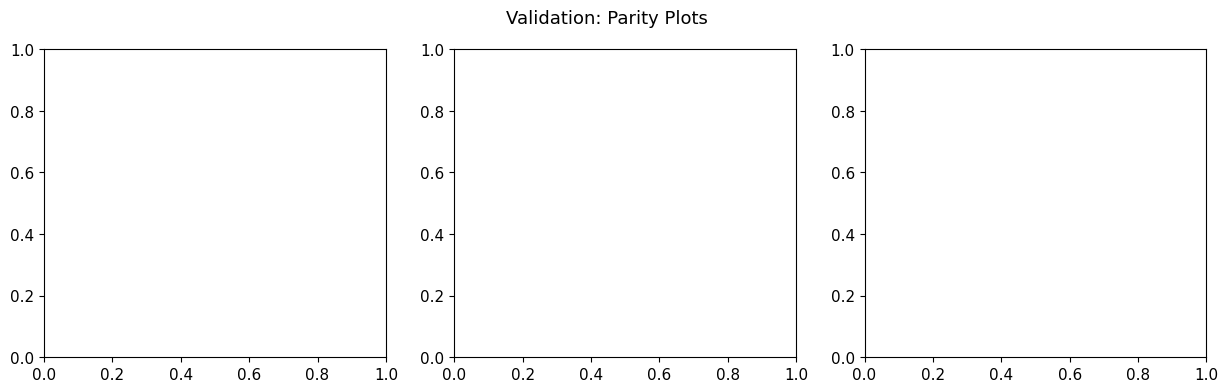

In [16]:
# ============================================================
# VALIDATION ON HELD-OUT DATA
# ============================================================

# Build validation library with same column definitions
vx_v    = X_val[:, 0]
vy_v    = X_val[:, 1]
omega_v = X_val[:, 2]
af_v    = X_val[:, 3]
ar_v    = X_val[:, 4]
delta_v = U_val[:, 0]
Tr_v    = U_val[:, 1]

# Rebuild all 17 candidate columns on validation data
val_cols = []
val_cols.append(omega_v * vy_v)
val_cols.append(omega_v * vx_v)
val_cols.append(vx_v.copy())
val_cols.append(vy_v.copy())
val_cols.append(Tr_v.copy())
val_cols.append(delta_v.copy())
val_cols.append(af_v * np.sin(delta_v))
val_cols.append(af_v * np.cos(delta_v))
val_cols.append(af_v**3 * np.sin(delta_v))
val_cols.append(af_v**3 * np.cos(delta_v))
val_cols.append(af_v**5 * np.sin(delta_v))
val_cols.append(af_v**5 * np.cos(delta_v))
val_cols.append(ar_v.copy())
val_cols.append(ar_v**3)
val_cols.append(ar_v**5)
val_cols.append(vx_v * af_v * np.cos(delta_v))
val_cols.append(vx_v * ar_v)

Theta_val_full = np.column_stack(val_cols)

# Apply same collinearity removal (keep same column indices as training)
# Map lib_names back to original column indices
orig_indices = [theta_names.index(name) for name in lib_names]
Theta_val_lib = Theta_val_full[:, orig_indices]

print("=== Validation Results ===\n")

# R² on validation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Validation: Parity Plots', fontsize=13)

for c, (ax, ch_name) in enumerate(zip(axes, channel_names)):
    pr = pruning_results[ch_name]
    # Map active indices from lib_names to Theta_val_lib columns
    active_lib = [lib_names.index(n) for n in pr['names']]
    Theta_val_A = Theta_val_lib[:, active_lib]
    xdot_pred_val = Theta_val_A @ pr['mu']
    y_true = Xd_val[:, c]
    r2_val = r_squared(y_true, xdot_pred_val)

    ax.scatter(y_true, xdot_pred_val, s=1, alpha=0.15, rasterized=True)
    lo, hi = min(y_true.min(), xdot_pred_val.min()), max(y_true.max(), xdot_pred_val.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    ax.set_xlabel(f'True {ch_name}')
    ax.set_ylabel(f'Predicted {ch_name}')
    ax.set_title(f'Val R² = {r2_val:.6f}')
    ax.grid(True, alpha=0.3)

    print(f"  {ch_name}: R²_val = {r2_val:.7f}")

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# VALIDATION — Coverage calibration on held-out data
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Validation: Calibration Curves (Held-Out)', fontsize=13)

for c, (ax, ch_name) in enumerate(zip(axes, channel_names)):
    pr = pruning_results[ch_name]
    active_lib = [lib_names.index(n) for n in pr['names']]
    Theta_val_A = Theta_val_lib[:, active_lib]
    mu_pred_val = Theta_val_A @ pr['mu']
    Sigma_A = pr['Sigma']

    param_var_val = np.sum((Theta_val_A @ Sigma_A) * Theta_val_A, axis=1)
    sigma_pred_val = np.sqrt(sigma_eps_per_ch[ch_name]**2 + param_var_val)

    residual_val = Xd_val[:, c] - mu_pred_val

    coverages_val = []
    for alpha in confidence_levels:
        z = norm.ppf(1 - (1 - alpha) / 2)
        in_interval = np.abs(residual_val) <= z * sigma_pred_val
        coverages_val.append(in_interval.mean())

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')
    ax.plot(confidence_levels, coverages_val, 'ro-', ms=8, lw=2, label='Val')
    ax.set_xlabel('Predicted coverage')
    ax.set_ylabel('Actual coverage')
    ax.set_title(ch_name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.4, 1.02)
    ax.set_ylim(0.4, 1.02)

    for alpha, cov in zip(confidence_levels, coverages_val):
        flag = "✓" if abs(cov - alpha) < 0.05 else "⚠"
        print(f"  {ch_name} {alpha*100:.0f}%: val_coverage={cov*100:.1f}%  {flag}")

plt.tight_layout()
plt.show()


### Time-Series Fit: Predicted vs True Derivatives


In [ ]:
# ============================================================
# TIME-SERIES COMPARISON (training data, best window)
# ============================================================

window = min(500, T_train)
metric = np.abs(Xd_train[:, 2])
energy = np.convolve(metric, np.ones(window), mode='valid')
best_start = int(np.argmax(energy))
idx_plot = np.arange(best_start, min(best_start + window, T_train))

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Time-Series Fit (Training, Most Active Window)', fontsize=13)

for c, (ax, ch_name) in enumerate(zip(axes, channel_names)):
    pr = pruning_results[ch_name]
    Theta_A = Theta_lib[:, pr['active']]
    xdot_pred = Theta_A @ pr['mu']

    y_true = Xd_train[idx_plot, c]
    y_pred = xdot_pred[idx_plot]

    ax.plot(idx_plot, y_true, 'k-', lw=1, label='True')
    ax.plot(idx_plot, y_pred, 'r--', lw=1, alpha=0.8, label='VINDy')
    ax.set_ylabel(ch_name)
    ax.grid(True, alpha=0.3)
    if c == 0:
        ax.legend(fontsize=9)

axes[-1].set_xlabel('Sample index')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# DEFINITIVE CHECK: Fresh nominal trajectory
# ============================================================

def pacejka(alpha, B, C, D, E):
    Ba = B * alpha
    return D * np.sin(C * np.arctan(Ba - E * (Ba - np.arctan(Ba))))

def get_curvature(s, seg_curvatures, cum_lengths, total_length):
    s = s % total_length
    for i, cl in enumerate(cum_lengths):
        if s < cl:
            return seg_curvatures[i]
    return seg_curvatures[-1]

# Track geometry
R_turn = 80.0; L_straight = 150.0
seg_curvatures = np.array([0.0, 1.0/R_turn, 0.0, 1.0/R_turn])
seg_lengths = np.array([L_straight, np.pi*R_turn, L_straight, np.pi*R_turn])
cum_lengths = np.cumsum(seg_lengths)
total_length = cum_lengths[-1]

# Nominal parameters
p = dict(nom)
p['lr'] = (p['lf'] + p['lr']) - p['lf']  # just in case
L_wb = p['lf'] + p['lr']

# Controller gains
ctrl = {'Ld_min': 8.0, 'Kla': 0.6, 'Kp_speed': 3000.0,
        'K_delta': 10.0, 'K_T': 15.0,
        'delta_max': 30.0*np.pi/180, 'Tr_max': 5000.0,
        'u1_max': 2.0, 'u2_max': 15000.0}

dt = 0.005
ds_factor = 6
v_refs_nom = [15, 25]

X_nom_list, Xd_nom_list, U_nom_list = [], [], []

for v_ref in v_refs_nom:
    x = np.array([0.0, 0.0, 0.0, float(v_ref), 0.0, 0.0, 0.0, 0.0])
    t_max = 1 * total_length / max(v_ref, 3.0) * 1.5
    N_steps = int(np.ceil(t_max / dt))

    lap_count = 0; s_prev = 0.0

    for k in range(N_steps):
        s_cur = x[0]
        if np.floor(s_cur / total_length) > np.floor(s_prev / total_length):
            lap_count += 1
            if lap_count >= 1: break
        s_prev = s_cur

        kap = get_curvature(s_cur, seg_curvatures, cum_lengths, total_length)

        # Steering
        Ld = ctrl['Ld_min'] + ctrl['Kla'] * max(x[3], 1.0)
        kap_la = get_curvature(s_cur + Ld, seg_curvatures, cum_lengths, total_length)
        delta_ff = np.arctan(L_wb * kap_la)
        e_la = x[1] + Ld * np.sin(x[2])
        delta_fb = -np.arctan(2.0 * L_wb * e_la / Ld**2)
        delta_des = np.clip(delta_ff + delta_fb, -ctrl['delta_max'], ctrl['delta_max'])

        # Speed
        e_v = v_ref - x[3]
        T_des = np.clip(ctrl['Kp_speed'] * e_v, -ctrl['Tr_max'], ctrl['Tr_max'])

        u1 = np.clip(ctrl['K_delta'] * (delta_des - x[6]), -ctrl['u1_max'], ctrl['u1_max'])
        u2 = np.clip(ctrl['K_T'] * (T_des - x[7]), -ctrl['u2_max'], ctrl['u2_max'])

        # Slip angles
        vy_f = x[4] + x[5] * p['lf']
        v_lat = vy_f * np.cos(x[6]) - x[3] * np.sin(x[6])
        v_lon = x[3] * np.cos(x[6]) + vy_f * np.sin(x[6])
        af = -np.arctan2(v_lat, max(abs(v_lon), 0.5))
        ar = -np.arctan2(x[4] - x[5] * p['lr'], max(abs(x[3]), 0.5))

        # Forces
        Ffc = pacejka(af, p['B_f'], p['C_f'], p['D_f'], p['E_f'])
        Frc = pacejka(ar, p['B_r'], p['C_r'], p['D_r'], p['E_r'])
        Frl = x[7] / p['R_wheel']

        # RHS (k1)
        denom = max(1.0 - x[1] * kap, 0.01)
        k1 = np.zeros(8)
        k1[0] = (x[3]*np.cos(x[2]) - x[4]*np.sin(x[2])) / denom
        k1[1] = x[3]*np.sin(x[2]) + x[4]*np.cos(x[2])
        k1[2] = x[5] - kap*k1[0]
        k1[3] = x[5]*x[4] + Frl/p['M'] - Ffc*np.sin(x[6])/p['M']
        k1[4] = -x[5]*x[3] + Frc/p['M'] + Ffc*np.cos(x[6])/p['M']
        k1[5] = (1.0/p['Jz'])*(-Frc*p['lr'] + Ffc*p['lf']*np.cos(x[6]))
        k1[6] = u1; k1[7] = u2

        # Save downsampled
        if k % ds_factor == 0 and x[3] > 1.0:
            X_nom_list.append([x[3], x[4], x[5], af, ar])
            Xd_nom_list.append([k1[3], k1[4], k1[5]])
            U_nom_list.append([x[6], x[7]])

        # RK4 (k2, k3, k4 abbreviated — reuse same ODE)
        def ode_rhs(xx, uu):
            kk = get_curvature(xx[0], seg_curvatures, cum_lengths, total_length)
            vyf = xx[4]+xx[5]*p['lf']
            vl = vyf*np.cos(xx[6])-xx[3]*np.sin(xx[6])
            vn = xx[3]*np.cos(xx[6])+vyf*np.sin(xx[6])
            a_f = -np.arctan2(vl, max(abs(vn),0.5))
            a_r = -np.arctan2(xx[4]-xx[5]*p['lr'], max(abs(xx[3]),0.5))
            Ff = pacejka(a_f, p['B_f'],p['C_f'],p['D_f'],p['E_f'])
            Fr = pacejka(a_r, p['B_r'],p['C_r'],p['D_r'],p['E_r'])
            Fl = xx[7]/p['R_wheel']
            dd = max(1.0-xx[1]*kk,0.01)
            dx = np.zeros(8)
            dx[0] = (xx[3]*np.cos(xx[2])-xx[4]*np.sin(xx[2]))/dd
            dx[1] = xx[3]*np.sin(xx[2])+xx[4]*np.cos(xx[2])
            dx[2] = xx[5]-kk*dx[0]
            dx[3] = xx[5]*xx[4]+Fl/p['M']-Ff*np.sin(xx[6])/p['M']
            dx[4] = -xx[5]*xx[3]+Fr/p['M']+Ff*np.cos(xx[6])/p['M']
            dx[5] = (1.0/p['Jz'])*(-Fr*p['lr']+Ff*p['lf']*np.cos(xx[6]))
            dx[6] = uu[0]; dx[7] = uu[1]
            return dx

        u = np.array([u1, u2])
        kk2 = ode_rhs(x + dt/2*k1, u)
        kk3 = ode_rhs(x + dt/2*kk2, u)
        kk4 = ode_rhs(x + dt*kk3, u)
        x = x + (dt/6)*(k1 + 2*kk2 + 2*kk3 + kk4)

        if abs(x[1]) > 50 or x[3] < 0.1: break

X_nom = np.array(X_nom_list)
Xd_nom = np.array(Xd_nom_list)
U_nom = np.array(U_nom_list)

print(f"Nominal trajectory: {len(X_nom)} samples")

# Build library on nominal data
vx_n = X_nom[:,0]; vy_n = X_nom[:,1]; om_n = X_nom[:,2]
af_n = X_nom[:,3]; ar_n = X_nom[:,4]
de_n = U_nom[:,0]; Tr_n = U_nom[:,1]

nom_cols = [om_n*vy_n, om_n*vx_n, vx_n, vy_n, Tr_n, de_n,
            af_n*np.sin(de_n), af_n*np.cos(de_n),
            af_n**3*np.sin(de_n), af_n**3*np.cos(de_n),
            af_n**5*np.sin(de_n), af_n**5*np.cos(de_n),
            ar_n, ar_n**3, ar_n**5,
            vx_n*af_n*np.cos(de_n), vx_n*ar_n]
Theta_nom_full = np.column_stack(nom_cols)
orig_indices = [theta_names.index(name) for name in lib_names]
Theta_nom_lib = Theta_nom_full[:, orig_indices]

# R² on nominal trajectory
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('DEFINITIVE CHECK: Nominal Trajectory R²', fontsize=14)

for c, (ax, ch_name) in enumerate(zip(axes, channel_names)):
    pr = pruning_results[ch_name]
    active_lib = [lib_names.index(n) for n in pr['names']]
    Theta_A = Theta_nom_lib[:, active_lib]
    y_pred = Theta_A @ pr['mu']
    y_true = Xd_nom[:, c]
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

    ax.scatter(y_true, y_pred, s=1, alpha=0.3, rasterized=True)
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    ax.set_xlabel(f'True {ch_name}')
    ax.set_ylabel(f'Predicted {ch_name}')
    ax.set_title(f'R² = {r2:.4f}')
    ax.grid(True, alpha=0.3)
    print(f"  {ch_name}: R² = {r2:.6f}")

plt.tight_layout()
plt.show()

### Coefficient Bar Chart with Uncertainty


In [ ]:
# ============================================================
# COEFFICIENT BAR CHART — μ ± 2σ per channel
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Posterior Coefficients: μ ± 2σ (per channel)', fontsize=13)

for c, (ax, ch_name) in enumerate(zip(axes, channel_names)):
    pr = pruning_results[ch_name]
    x_pos = np.arange(len(pr['names']))

    colors = []
    for j in range(len(pr['mu'])):
        cov = pr['sigma'][j] / abs(pr['mu'][j]) if abs(pr['mu'][j]) > 1e-15 else 999
        if cov < 0.2:
            colors.append('#2ecc71')   # green = confident
        elif cov < 0.5:
            colors.append('#f39c12')   # orange = moderate
        else:
            colors.append('#e74c3c')   # red = uncertain

    ax.bar(x_pos, pr['mu'], yerr=2*pr['sigma'], color=colors, edgecolor='k',
           capsize=4, alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(pr['names'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(ch_name)
    ax.axhline(0, color='k', lw=0.5)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_title(f'{ch_name}: {len(pr["names"])} active terms')

plt.tight_layout()
plt.show()

print("Legend: 🟢 confident (CoV<0.2), 🟠 moderate (CoV<0.5), 🔴 uncertain (CoV≥0.5)")


## Summary


In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 70)
print("  VINDy-C IDENTIFICATION SUMMARY")
print("=" * 70)

print(f"\n  σ_ε per channel:")
for ch, se in sigma_eps_per_ch.items():
    print(f"    {ch}: {se:.6f}")
print(f"  γ (SNR threshold) = {gamma}")
print(f"  Training samples = {T_train}")
print(f"  Validation samples = {T_val}")
print(f"  Initial library size = {p_lib}")

print(f"\n  {'Channel':<12s}  {'Active':>7s}  {'Pruned':>7s}  {'R²_train':>10s}  {'R²_val':>10s}")
print("  " + "-"*50)

for c, ch_name in enumerate(channel_names):
    pr = pruning_results[ch_name]
    Theta_A = Theta_lib[:, pr['active']]
    r2_train = r_squared(Xd_train[:, c], Theta_A @ pr['mu'])

    active_lib = [lib_names.index(n) for n in pr['names']]
    Theta_val_A = Theta_val_lib[:, active_lib]
    r2_val = r_squared(Xd_val[:, c], Theta_val_A @ pr['mu'])

    print(f"  {ch_name:<12s}  {len(pr['active']):7d}  "
          f"{p_lib - len(pr['active']):7d}  {r2_train:10.7f}  {r2_val:10.7f}")

print(f"\n  Identified equations:")
for ch_name in channel_names:
    pr = pruning_results[ch_name]
    terms = []
    for j, name in enumerate(pr['names']):
        coef = pr['mu'][j]
        terms.append(f"{coef:+.6f}·{name}")
    eq = " ".join(terms)
    print(f"\n  {ch_name} = {eq}")

print("\n" + "=" * 70)
print("  Output for SMPC:")
print("  → μ_tire, Σ_tire from vy_dot channel posterior")
print("  → Sample scenarios: ξ ~ N(μ_tire, Σ_tire)")
print("=" * 70)
